<a href="https://colab.research.google.com/github/camistrika/BETO_HUMOR/blob/main/notebooks/final_model_lora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo final — BETO + LoRA

In [12]:
!git clone https://github.com/camistrika/BETO_HUMOR.git
%cd BETO_HUMOR
!pip install -e . -q

Cloning into 'BETO_HUMOR'...
remote: Enumerating objects: 166, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 166 (delta 75), reused 152 (delta 68), pack-reused 0 (from 0)
Receiving objects: 100% (166/166), 3.36 MiB | 4.85 MiB/s, done.
Resolving deltas: 100% (75/75), done.
/content/BETO_HUMOR/BETO_HUMOR
  Preparing metadata (setup.py) ... done


In [1]:
!pip install -q torchao --upgrade
!pip install -q transformers peft datasets scikit-learn pyyaml

In [2]:
%cd /content/BETO_HUMOR

/content/BETO_HUMOR


In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
import shutil
from google.colab import files

from betohumor.config import DataConfig, BetoConfig, LoraConfig
from betohumor.utils import set_seed
from betohumor.dataset import load_and_split, HahaDataset
from betohumor.models.lora import build_beto_lora
from betohumor.train import train_model
from betohumor.metrics import get_best_macro_f1_from_history, get_training_history
from betohumor.plots import plot_training_curves

## 1. Mejor configuración (resultado del CV)
Completar con los valores reales que ganaron en `cross_validation_lora.ipynb`.

In [4]:
BEST_R     = 32
BEST_ALPHA = 64
BEST_LR    = 1e-4
BEST_WD    = 0.05

## 2. Datos: train + val combinados
Se separa una porción chica (5%) solo para que el Trainer tenga con qué
medir el early stopping — no para elegir hiperparámetros, eso ya está
decidido por el CV.

In [5]:
data_config  = DataConfig(data_path = "data/raw/haha_2019_train.csv")
beto_config = BetoConfig()
set_seed(data_config.seed)

df_train, df_val, df_test = load_and_split(data_config)
df_combined = pd.concat([df_train, df_val]).reset_index(drop=True)

df_train_final, df_val_final = train_test_split(
    df_combined, test_size=0.05,
    stratify=df_combined[data_config.label_col],
    random_state=data_config.seed,
)

print(f'Train final: {len(df_train_final)} | Val: {len(df_val_final)}')

Train: 19197 | Val: 2397 | Test: 2400
Train final: 20514 | Val: 1080


## 3. Entrenar el modelo final

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(beto_config.base_model)

train_dataset = HahaDataset(df_train_final, tokenizer, data_config)
val_dataset   = HahaDataset(df_val_final,   tokenizer, data_config)

lora_config = LoraConfig(r=BEST_R, lora_alpha=BEST_ALPHA)
model = build_beto_lora(beto_config, lora_config)

trainer = train_model(
    model, train_dataset, val_dataset, beto_config,
    output_dir='results/final_lora',
    seed=data_config.seed,
    learning_rate=BEST_LR,
    weight_decay=BEST_WD,
)

## 4. Curva de entrenamiento

Macro F1: 0.8676


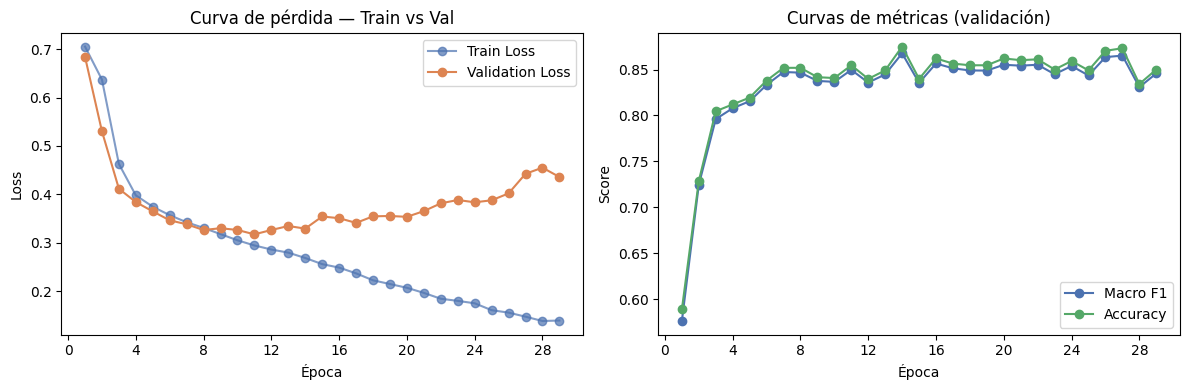

In [17]:
history = get_training_history(trainer)
macro_f1 = get_best_macro_f1_from_history(trainer)

print(f'Macro F1: {macro_f1:.4f}')
_ = plot_training_curves(history)

## 5. Guardar el modelo final

In [8]:
trainer.save_model('results/final_lora')
tokenizer.save_pretrained('results/final_lora')

('results/final_lora/tokenizer_config.json',
 'results/final_lora/tokenizer.json')

In [9]:
shutil.make_archive('final_lora', 'zip', 'results/final_lora')
files.download('final_lora.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
df_history = pd.DataFrame({
    'epoch': history['eval_epochs'],
    'eval_loss': history['eval_loss'],
    'macro_f1': history['macro_f1'],
    'accuracy': history['accuracy'],
})
df_history['best_macro_f1'] = macro_f1

df_history.to_csv('results/final_lora/training_val.csv', index=False)

In [16]:
files.download('results/final_lora/training_val.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
df_train_history = pd.DataFrame({
    'epoch': history['train_epochs'],
    'train_loss': history['train_loss'],
})

df_train_history.to_csv('results/final_lora/training_loss.csv', index=False)

In [14]:
files.download('results/final_lora/training_loss.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>